The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


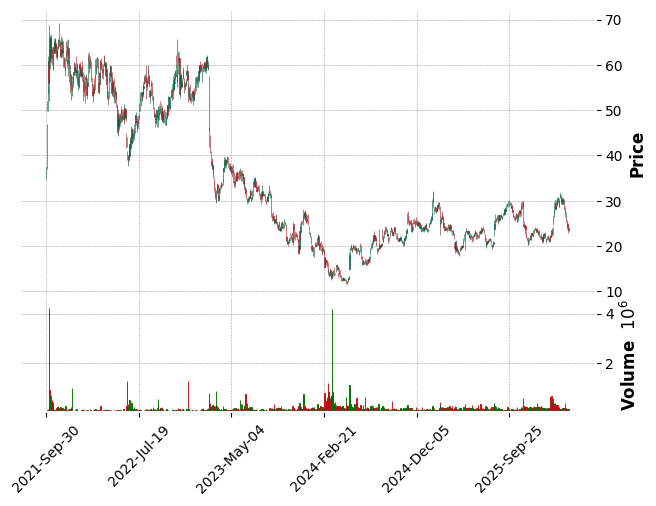

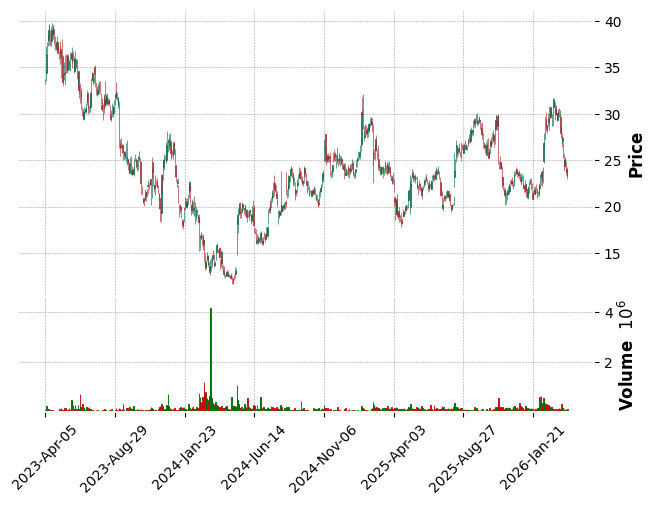

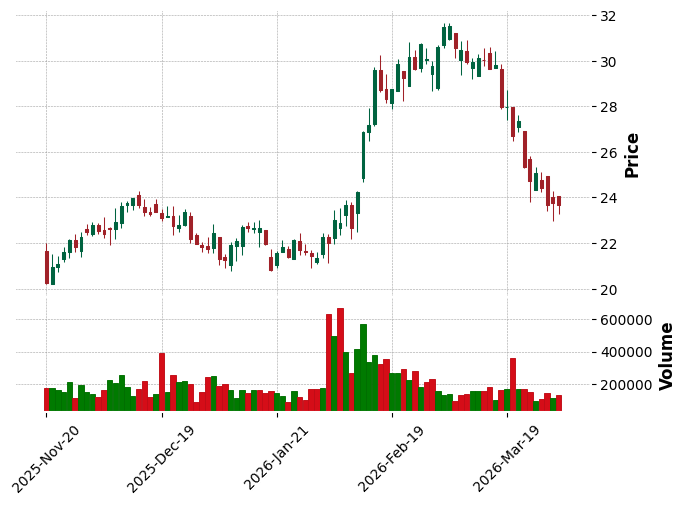

In [15]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
stockName = 'CCSI'
Fun = Fundamentals(stockName)

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-90:], type='candle', style='charles',volume=True)

In [16]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [ ]:
#peers, avg_price = Fun.get_peers()
#print(avg_price)
#sns.barplot(x=peers.index, y=peers['Price'])
#plt.show()

yfinance does not provide a direct peers endpoint. Please pass a list of tickers manually.
None


KeyError: 'Price'

In [22]:
fairValues = Fun.calculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [23]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [24]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

Moderate Insider Conviction (Insiders: 3.72%, Inst: 107.95%)


In [37]:
news = Fun.get_news()



[{'date': '2026-02-24 11:51:55',
  'headline': 'Consensus Cloud Solutions (CCSI) Reports Q4 2025 Revenue of '
              '$87.07M and 13.7% Growth in Adjusted EPS',
  'publisher': 'Insider Monkey',
  'url': 'https://finance.yahoo.com/news/consensus-cloud-solutions-ccsi-reports-115155041.html'}]
[{'date': '2026-02-24 11:51:55',
  'headline': 'Consensus Cloud Solutions (CCSI) Reports Q4 2025 Revenue of '
              '$87.07M and 13.7% Growth in Adjusted EPS',
  'publisher': 'Insider Monkey',
  'url': 'https://finance.yahoo.com/news/consensus-cloud-solutions-ccsi-reports-115155041.html'},
 {'date': '2026-02-19 11:55:38',
  'headline': 'Here’s What Hurt Consensus Cloud Solutions’ (CCSI) Positive '
              'Momentum',
  'publisher': 'Insider Monkey',
  'url': 'https://finance.yahoo.com/news/hurt-consensus-cloud-solutions-ccsi-115538796.html'}]
[{'date': '2026-02-24 11:51:55',
  'headline': 'Consensus Cloud Solutions (CCSI) Reports Q4 2025 Revenue of '
              '$87.07M and 1

Average Weighted EPS: 1.0523
Lower Standard Deviation: 0.8102614658650965
Upper Standard Deviation: 1.2943385341349034
Total Debt/Total Equity: 40.5408


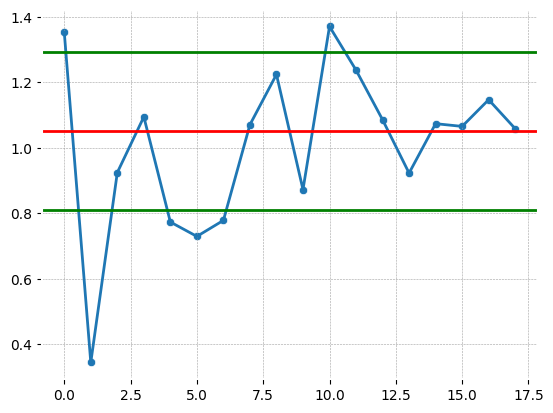

In [ ]:
try:
    inflect = Fun.get_inflections()
except:
    pass

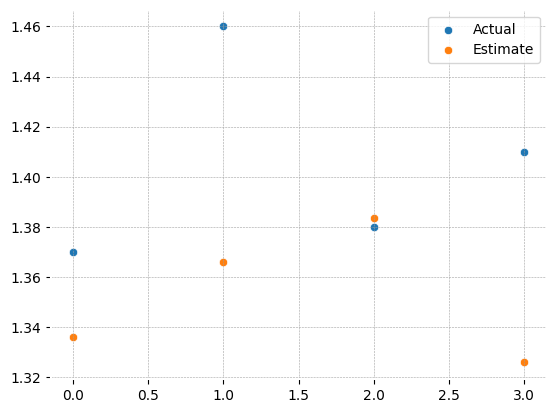

In [ ]:
surprise = Fun.eps_surprise()

Revenue Trend: [3.62422e+08 3.62562e+08 3.50382e+08 3.49696e+08]


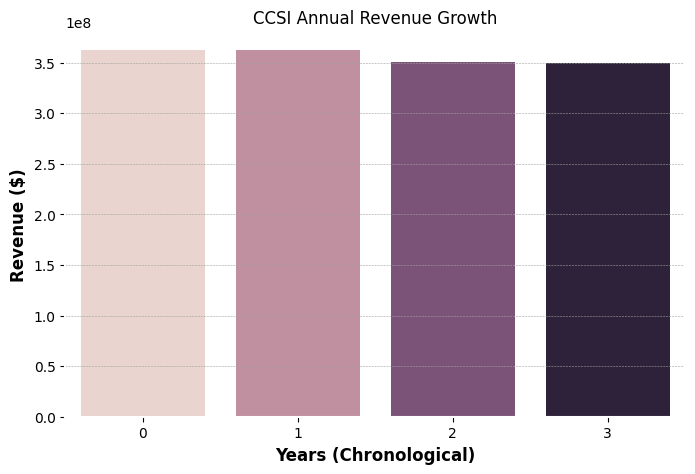

In [30]:
revenue = Fun.revenue_growth()

In [27]:
dcf = Fun.calculate_dcf()

Current FCF for CCSI: $105,853,000.00
{'Current Price': 23.67,
 'Enterprise Value': 1662858661.58,
 'Intrinsic Price': 61.84,
 'Ticker': 'CCSI'}


--- Profitability Analysis: CCSI ---

Annual Net Income History:
2021-12-31           NaN
2022-12-31   72714000.00
2023-12-31   77295000.00
2024-12-31   89435000.00
2025-12-31   84527000.00
Name: Net Income, dtype: float64

Last 4 Quarters Net Income:
2025-03-31   21152000.00
2025-06-30   20781000.00
2025-09-30   22091000.00
2025-12-31   20503000.00
Name: Net Income, dtype: float64


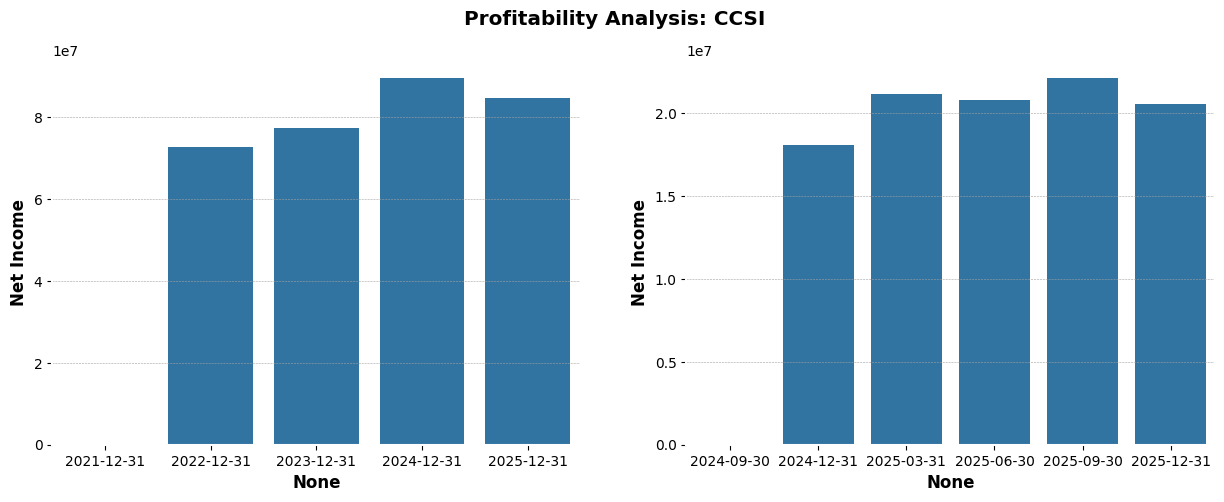

(2021-12-31           NaN
 2022-12-31   72714000.00
 2023-12-31   77295000.00
 2024-12-31   89435000.00
 2025-12-31   84527000.00
 Name: Net Income, dtype: float64,
 2024-09-30           NaN
 2024-12-31   18071000.00
 2025-03-31   21152000.00
 2025-06-30   20781000.00
 2025-09-30   22091000.00
 2025-12-31   20503000.00
 Name: Net Income, dtype: float64)

In [28]:
Fun.check_profitability()

--- FCF Analysis for CCSI ---

Annual FCF Trend:
2021-12-31            NaN
2022-12-31    52104000.00
2023-12-31    77652000.00
2024-12-31    88307000.00
2025-12-31   105853000.00
Name: Free Cash Flow, dtype: float64


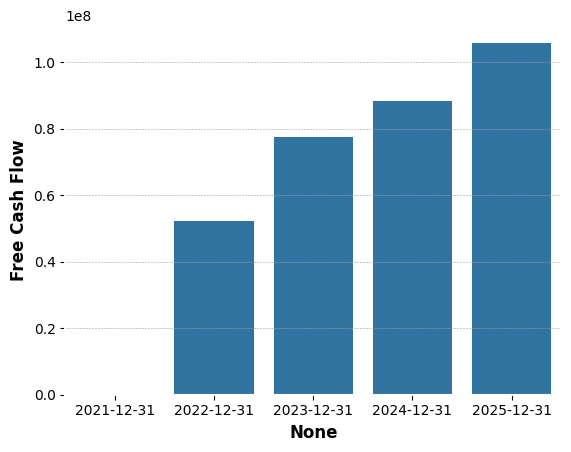

Annual Direction: INCREASING (17,546,000)

Quarterly FCF Trend (Last 4 Quarters):
2025-03-31   33747000.00
2025-06-30   20345000.00
2025-09-30   44441000.00
2025-12-31    7320000.00
Name: Free Cash Flow, dtype: float64


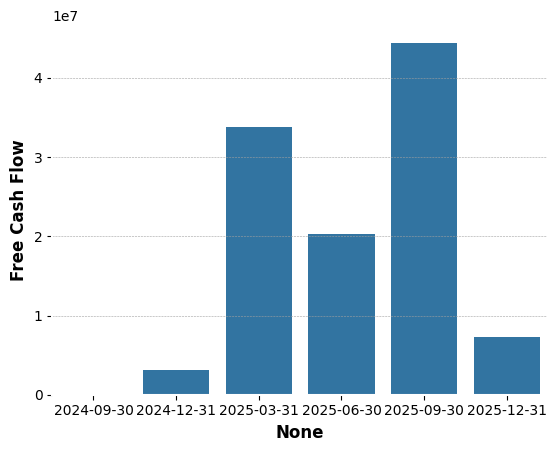

Recent Quarterly Direction: DECREASING (-37,121,000)


In [29]:
Fun.check_fcf_trend()